# Mini-CNN Project

In this notebook we aim to implement a mini Convolutional Neural Network (CNN) using keras and numpy.                                       

The dataset we use is [hoda handwritten farsi digit](https://farsiocr.ir/مجموعه-داده/مجموعه-ارقام-دستنویس-هدی).

### Objectives:

* [Preprocessing](#Preprocessing)

* [CNN with Keras](#CNN-with-Keras)

* [CNN from Scratch](#CNN-from-Scratch)

In [1]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.io import loadmat
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils  import to_categorical, plot_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

## Preprocessing

In [8]:
# Load data

dataset = loadmat('dataset/Data_hoda_full.mat')


In [9]:
dataset.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])

In [10]:
# Define data and labels

data = dataset['Data']
label = dataset['labels']


In [11]:
labels = set(int(y) for y in label.flatten())
print(f"Labels: {labels}")

Labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [12]:
# Number of samples per each class

pd.Series(label.flatten()).value_counts().sort_index()


0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64

In [13]:
print(f"Size of data: {data.shape}\nType: {type(data)}")

Size of data: (60000, 1)
Type: <class 'numpy.ndarray'>


In [14]:
print(f"Size of labels: {label.shape}\nType: {type(label)}")

Size of labels: (60000, 1)
Type: <class 'numpy.ndarray'>


In [9]:
# Remove axes of length 1 from the array

X = np.squeeze(data)
y = np.squeeze(label)


In [84]:
print(f"Shape of data: {X.shape}")

Shape of data: (60000,)


In [11]:
# We have different image sizes

for _ in range(4):
    idx = np.random.randint(len(X))
    print(X[idx].shape)


(29, 22)
(50, 8)
(30, 17)
(43, 21)


In [12]:
# So resize them

X_resize = [cv2.resize(img, (28, 28)) for img in X]


In [13]:
for _ in range(4):
    idx = np.random.randint(len(X_resize))
    print(X_resize[idx].shape)

(28, 28)
(28, 28)
(28, 28)
(28, 28)


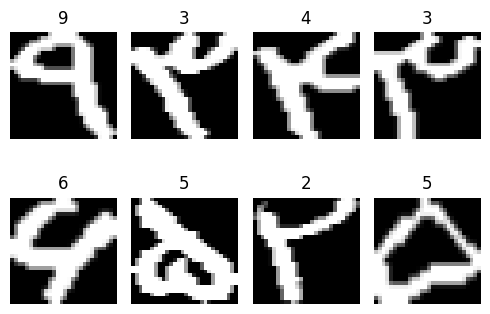

In [83]:
# Display some images

fig, axes = plt.subplots(2, 4, figsize=(5, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X_resize))
    img = X_resize[idx]
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(y[idx])
    plt.tight_layout()

In [15]:
# Create a data frame of data

X_array = np.array(X_resize)  # convert the list to numpy array

X_reshape = np.reshape(X_array, (-1, 28*28*1))  # flatten it to use in data frame

df = pd.DataFrame(X_reshape)

df['label'] = y

In [16]:
df

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0,0,0,0,0,109,255,255,109,0,...,0,0,0,0,0,0,0,0,0,6
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
2,0,77,214,255,255,255,255,255,255,255,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
59996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
59997,0,77,214,255,255,255,255,123,0,0,...,0,0,0,0,0,0,0,0,0,2
59998,0,0,0,0,0,0,0,0,0,155,...,0,0,0,0,0,0,0,0,0,6


In [17]:
df.shape

(60000, 785)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, 0 to label
dtypes: uint8(785)
memory usage: 44.9 MB


In [19]:
type(df)

pandas.DataFrame

In [20]:
df.dtypes

0        uint8
1        uint8
2        uint8
3        uint8
4        uint8
         ...  
780      uint8
781      uint8
782      uint8
783      uint8
label    uint8
Length: 785, dtype: object

In [21]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,13.250833,21.065000,28.533883,32.168567,34.596633,37.347050,41.119600,45.740917,50.753450,55.701733,...,42.207350,40.234333,39.455200,40.614967,44.174967,49.655783,53.496517,48.076633,33.366900,4.500000
std,54.159315,63.252291,72.909973,76.682218,79.309979,82.380479,85.685365,89.426884,93.352951,96.701224,...,87.374205,85.425007,84.402883,84.669648,86.838818,91.290755,95.432858,91.379426,83.100549,2.872305
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.500000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,17.000000,36.000000,68.000000,...,4.000000,1.000000,2.000000,6.000000,18.000000,36.000000,55.000000,18.000000,0.000000,7.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,9.000000


In [24]:
# Remove duplicate images

df_clean = df.drop_duplicates()
idx = df_clean.index

X_clean = X_array[idx]
y_clean = y[idx]

print(f"Original samples: {len(X_resize)}")
print(f"Unique samples: {len(X_clean)}")
print(f"Removed {len(X_resize) - len(X_clean)} duplicates")


Original samples: 60000
Unique samples: 59849
Removed 151 duplicates


In [25]:
X_clean.shape

(59849, 28, 28)

In [26]:
y_clean.shape

(59849,)

In [27]:
# Split data to train and test

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
                                                    X_clean,
                                                    y_clean,
                                                    test_size=0.2,
                                                    random_state=42
                                                    )


In [28]:
print(f'X_train shape: {X_train_clean.shape}')
print(f'X_test shape:  {X_test_clean.shape}')
print(f'y_train shape: {y_train_clean.shape}')
print(f'y_test shape:  {y_test_clean.shape}')

X_train shape: (47879, 28, 28)
X_test shape:  (11970, 28, 28)
y_train shape: (47879,)
y_test shape:  (11970,)


In [29]:
# Number of each label after splitting 

pd.Series(y_train_clean).value_counts().sort_index()


0    4705
1    4769
2    4713
3    4752
4    4791
5    4786
6    4816
7    4845
8    4818
9    4884
Name: count, dtype: int64

In [30]:
# Reshape them again to add channel dimension (required for CNN layers):
# (-1, 28, 28, 1) for grayscale images & (-1, 28, 28, 3) for RGB images

X_train = np.reshape(X_train_clean, (-1, 28, 28, 1))
X_test  = np.reshape(X_test_clean,  (-1, 28, 28, 1))


In [31]:
X_train.shape

(47879, 28, 28, 1)

In [32]:
# Convert data type to float32 & Scale to range [0-1] for better and faster training

x_train = X_train.astype('float32') / 255.0
x_test  = X_test.astype('float32')  / 255.0


In [33]:
print(f'X_train data type: {x_train.dtype}')

X_train data type: float32


In [34]:
print(f"Min pixel value: {x_train.min()}\nMax pixel value: {x_train.max()}")

Min pixel value: 0.0
Max pixel value: 1.0


In [35]:
# One-hot encode labels

y_train = to_categorical(y_train_clean)
y_test  = to_categorical(y_test_clean)


In [36]:
y_train_clean[:5]

array([9, 7, 2, 7, 4], dtype=uint8)

In [37]:
y_train[:5]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

## CNN with Keras

We define the model as follows:                                                                          

Input image → (Convolution layer → Pooling) x 2 → Flatten → Dense layer → Output

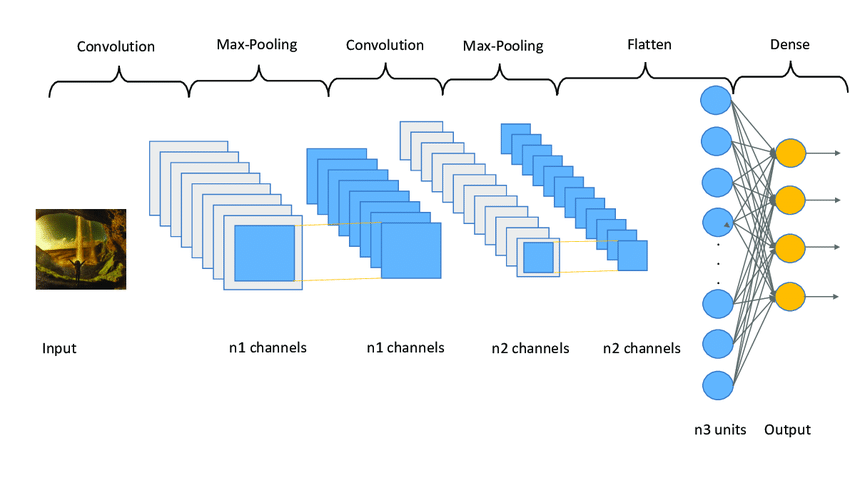

In [ ]:

if len(labels) == 2:
    activation = 'sigmoid'
else:
    activation = 'softmax'

model = Sequential(
    [
    Input((28, 28, 1)),             # 28x28 grayscale images
    Conv2D(filters=3, kernel_size=5, padding='same', activation='relu'),
    MaxPooling2D(2),                # pooling
    Conv2D(filters=5, kernel_size=3, padding='same', activation='relu'),
    MaxPooling2D(2),
    Flatten(),                      # can use GlobalAveragePooling2D too
    Dense(20, activation="relu"),   # fully connected layer
    Dense(len(labels), activation=activation) # output layer
    ],
    name='Mini-CNN'
)


# We could run the following in a high-performance computer:

"""model = Sequential([
    Input((28, 28, 1)),
    Conv2D(50, 5, activation="relu", padding="same"),
    MaxPooling2D(2),
    Conv2D(100, 3, activation="relu", padding="same"),
    MaxPooling2D(2),
    Conv2D(200, 3, activation="relu", padding="same"),
    MaxPooling2D(2),
    Flatten(),
    Dense(100, activation="relu"),
    Dropout(0.4),
    Dense(50, activation="relu"),
    Dropout(0.4),
    Dense(10, activation="softmax")],
    name='CNN')"""


In [39]:
model.summary()

Model: "Mini-CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 3)      │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 5)      │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 245)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         4,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,348 (20.89 KB)

 Trainable params: 5,348 (20.89 KB)

 Non-trainable params: 0 (0.00 B)

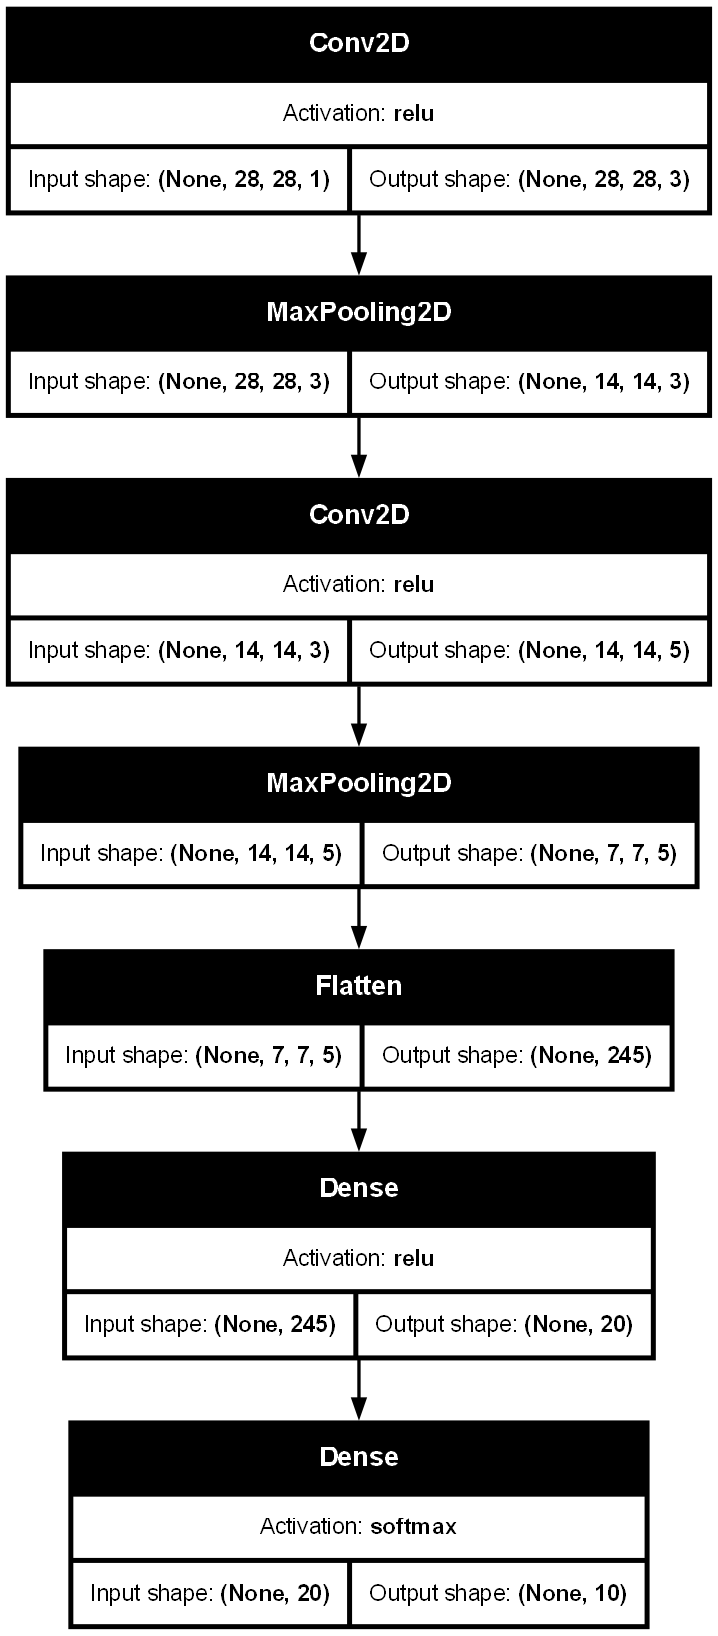

In [40]:
# Visualize model architecture

plot_model(model, show_shapes=True, show_layer_activations=True, dpi=120)


In [41]:
# Configure the model for training

model.compile(
    loss="categorical_crossentropy",  # for multi-class classification
    optimizer="adam",                 # adam optimizer for faster convergence
    metrics=["accuracy"]              # calculates accuracy during training/validation
    );


In [42]:
# Now train it

model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2  # 20 percent of training data
    );


Epoch 1/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8930 - loss: 0.3544 - val_accuracy: 0.9641 - val_loss: 0.1154
Epoch 2/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9720 - loss: 0.0932 - val_accuracy: 0.9750 - val_loss: 0.0813
Epoch 3/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9786 - loss: 0.0708 - val_accuracy: 0.9763 - val_loss: 0.0762
Epoch 4/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9825 - loss: 0.0586 - val_accuracy: 0.9827 - val_loss: 0.0582
Epoch 5/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9841 - loss: 0.0517 - val_accuracy: 0.9826 - val_loss: 0.0521
Epoch 6/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9856 - loss: 0.0453 - val_accuracy: 0.9845 - val_loss: 0.0524
Epoch 7/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9861 - loss: 0.0417 - val_accuracy: 0.9840 - val_loss: 0.0488
Epoch 8/10
599/599 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9887 - loss: 0.0368 - val

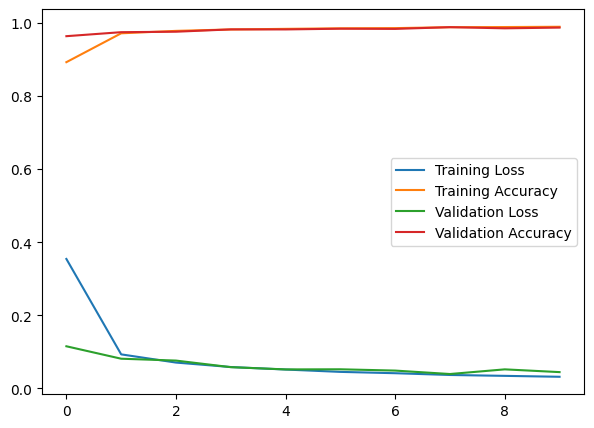

In [43]:
# Plot the loss and accuracy

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(model.history.history["loss"], label="Training Loss")
ax.plot(model.history.history["accuracy"], label="Training Accuracy")
ax.plot(model.history.history["val_loss"], label="Validation Loss")
ax.plot(model.history.history["val_accuracy"], label="Validation Accuracy")
ax.legend();


In [44]:
# Evaluate the model on Test data

test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test data accuracy: {test_acc * 100.0 :.2f}%")


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9877 - loss: 0.0414
Test data accuracy: 98.77%


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


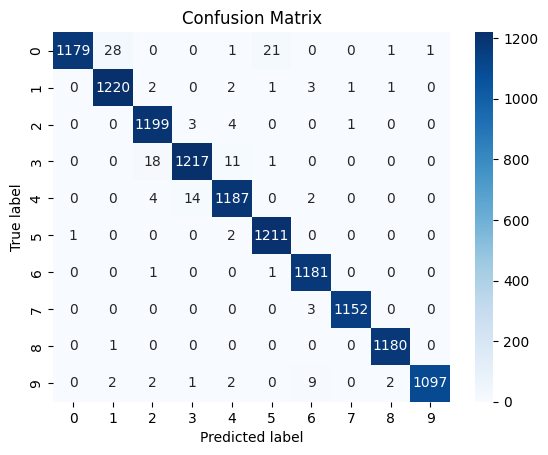

In [45]:
# Plot the confusion matrix

predicted = model.predict(x_test)
predicted_classes = np.argmax(predicted, axis=1)

cm = confusion_matrix(y_test_clean, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show();


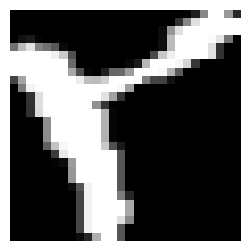

In [46]:
# Test a sample

idx = np.random.randint(len(x_test))
sample = x_test[idx].reshape((1, 28, 28, 1))

plt.figure(figsize=(3,3))
plt.imshow(sample.reshape((28,28)), cmap='gray')
plt.axis('off')
plt.show()


In [47]:
pred = model.predict(sample)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


array([[4.3438373e-09, 1.6686700e-09, 9.9997079e-01, 6.9724301e-06,
        1.2447055e-07, 3.5008441e-12, 4.2529379e-08, 2.2116075e-05,
        9.4050998e-15, 1.6627533e-12]], dtype=float32)

In [48]:
print(f"Predicted label = {pred.argmax()}")
print(f"True label = {y_test_clean[idx]}")

Predicted label = 2
True label = 2


In [49]:
# Save the model

model.save("Mini-CNN.keras")    # Keras format
# model.save("Mini-CNN.h5")     # HDF5  format


## CNN from Scratch

### Convolutional layer

The first layer we define is the convolutional layer.                                    

It applies convolution operations to input images by sliding a learnable kernel over them, computing dot products with patches of the input. This helps detect spatial features like edges and textures. The more filters we give to a convolutional layer, the more features it can see.                                                             



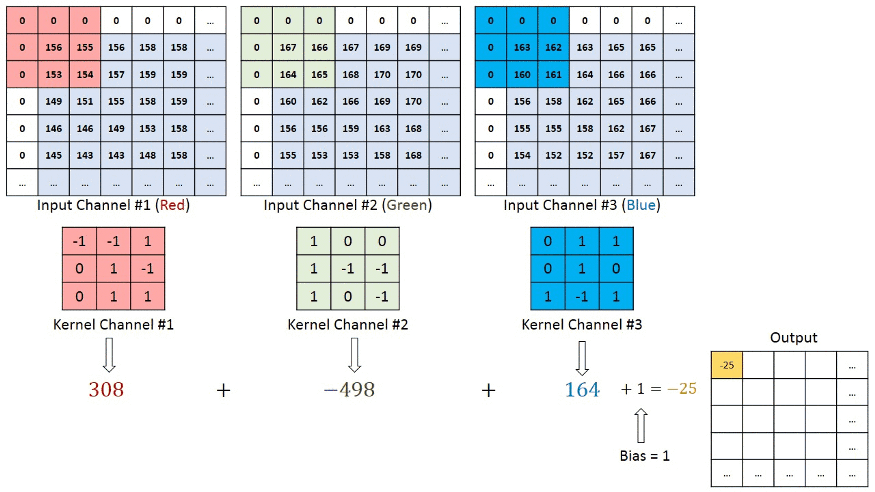

We will begin by looking at the hyper-parameters that we must specify for a
convolutional layer in most neural network frameworks that support the CNN:

* Number of filters                                       
* Filter Size                                                    
* Stride                                                       
* Padding                                                      
* Activation Function

#### kernels

The following image shows common filters/kernels we can use

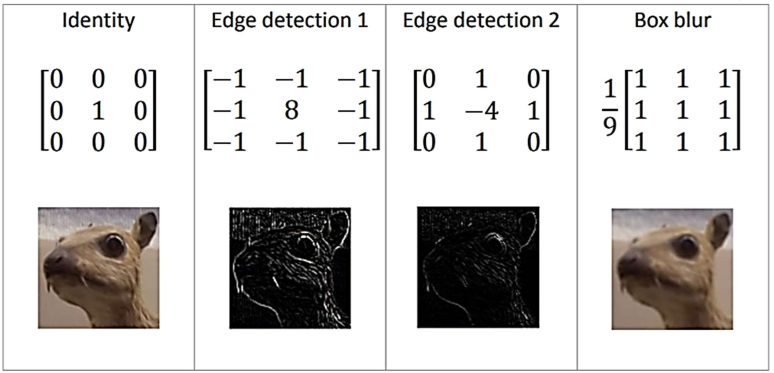

Number of Filters

This defines the depth of the output volume from the convolutional layer. Each filter learns to detect a specific type of feature (e.g., edges, corners, textures, or more complex patterns).

* K filters → K output channels

* Too few filters → the layer may miss important patterns
                                                 
* Too many → increased computational cost and risk of overfitting                                        



Filter Size

This is the spatial dimensions (height × width) of the filter, typically square (e.g., 3×3, 5×5, 7×7).

* Smaller filters (e.g., 3×3) stack well to create large receptive fields with fewer parameters.

* Larger filters capture more global context in one layer but increase parameter count.

#### Stride

The number of pixels by which the filter slides across the input image (or feature map) at each step, both vertically and horizontally.

* Stride = 1 → filter moves one pixel at a time

* Stride = 2 → filter jumps two pixels

* Larger stride reduces spatial dimensions and computation, but may skip important features.

#### Padding

Padding is the process of adding layers of zeros or other values outside the actual data in an input matrix. The primary purpose of padding is to preserve the spatial size of the input so that the output after applying filters (kernels) remains the same size, or to adjust it according to the desired output dimensions.

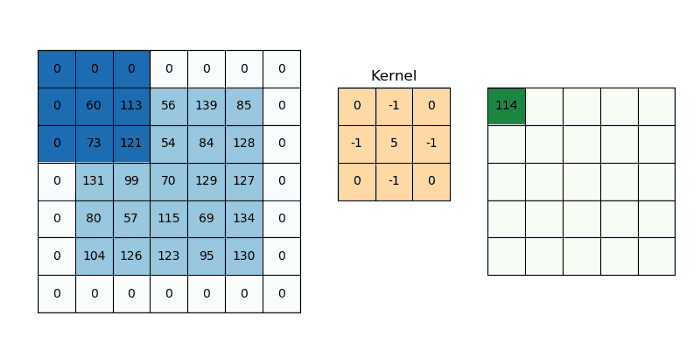

In [51]:
sample = np.array([
    [8,0,3,1,0],
    [2,4,0,2,9],
    [7,5,2,9,4],
    [5,6,2,8,6]
])

print(f'{sample}\n\nshape = {sample.shape}')

[[8 0 3 1 0]
 [2 4 0 2 9]
 [7 5 2 9 4]
 [5 6 2 8 6]]

shape = (4, 5)


In [52]:
def padding(sample, p=1):
    if p==0:
        return sample
    else:
        paded_img = np.zeros((sample.shape[0]+(p*2), sample.shape[1]+(p*2)))
        paded_img[p:-p, p:-p] = sample
        return paded_img

In [53]:
p = padding(sample, 1)
print(f'{p}\n\nshape = {p.shape}')

[[0. 0. 0. 0. 0. 0. 0.]
 [0. 8. 0. 3. 1. 0. 0.]
 [0. 2. 4. 0. 2. 9. 0.]
 [0. 7. 5. 2. 9. 4. 0.]
 [0. 5. 6. 2. 8. 6. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]

shape = (6, 7)


#### Activation Function

Applied after the convolution operation (but before passing to the next layer). It introduces non-linearity, allowing the network to learn complex patterns.
* ReLU (Rectified Linear Unit): f(x) = max(0, x). Fast, reduces vanishing gradient, introduces sparsity.

* Leaky ReLU – allows small negative values to avoid “dead neurons.”

* Sigmoid / Tanh – rarely used in modern CNNs due to saturation and vanishing gradient issues, but sometimes in output layers.

* Without non-linearity, multiple convolutional layers would collapse into a single linear transformation.

In [54]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1/(1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def elu(z, alpha=1.0):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

Now we implement the convolution layer

In [55]:
def convolution(sample, filter=None, filter_size=3, p=0, s=1, activation='relu'):
    
    if filter is None:
        filter = np.random.randint(-5, 10, size=(filter_size, filter_size))
        
    # bias is random from -1, 0, 1
    bias_conv = np.random.randint(-1, 2)  
    
    # pad the input
    paded = padding(sample, p)
    
    # activation function
    act = globals()[activation]
    
    # slide the filter over the padded image
    conved_list = []
    for i in range(0, paded.shape[0] - filter.shape[0] + 1, s):
        row_list = []
        for j in range(0, paded.shape[1] - filter.shape[1] + 1, s):
            # extract window and apply filter
            window = paded[i:i + filter.shape[0], j:j + filter.shape[1]]
            sum_conv = np.sum(window * filter)
            conv_value = sum_conv + bias_conv
            row_list.append(act(conv_value))
        conved_list.append(row_list)
    
    # convert to numpy array
    act_conv = np.array(conved_list)
    
    return act_conv

In [56]:
c = convolution(sample, filter_size=3, p=1, s=1, activation='relu')
print(f'{c}\n\nConvolved image shape: {c.shape}')

[[ 0. 67.  0.  0. 65.]
 [26. 92.  0. 94. 17.]
 [22. 63. 63. 52. 60.]
 [ 4. 64. 98. 16. 84.]]

Convolved image shape: (4, 5)


### Flatten layer

Converts a multi-dimensional tensor (e.g., 2D or 3D feature maps) into a single 1D vector.                             

A standard dense layer cannot directly process a 2D/3D feature map because each dense neuron expects a single scalar input per connection. Flattening reshapes the data without changing its values — just the structure.

In [57]:
def flatten(act_conv):
    flat = np.reshape(act_conv, -1)
    return flat

In [58]:
f = flatten(c)
f

array([ 0., 67.,  0.,  0., 65., 26., 92.,  0., 94., 17., 22., 63., 63.,
       52., 60.,  4., 64., 98., 16., 84.])

### Dense layer

A layer where every neuron in the input is connected to every neuron in the output. Each connection has its own learnable weight, and the output neuron also typically includes a learnable bias term.
                                                     
It typically appear at the end of a CNN, after all spatial feature extraction is complete. The dense layers act as the "classifier head" that makes decisions based on the features the convolutional layers extracted.

In [59]:
def dense(n, flat, activation='relu'):
    hidden_layer = np.zeros(n)
    h_s = hidden_layer.shape[0]
    
    # weight initialization (He method)
    sigma2_hidden = 2 / flat.shape[0]  
    weights_hidden = np.random.normal(0, np.sqrt(sigma2_hidden), (flat.shape[0], h_s))   
    bias_hidden = np.zeros(h_s)
    
    # forward pass
    act = globals()[activation]
    for j in range(h_s):
        sum_hidden = 0
        for i in range(flat.shape[0]):
            sum_hidden += flat[i] * weights_hidden[i][j]
        hidden_layer[j] = sum_hidden + bias_hidden[j]
    
    return act(hidden_layer)

In [60]:
d = dense(25, f, activation='relu')
d

array([  0.        ,  26.51083216,  67.27739162,   0.        ,
        26.13471128,  87.10615527,   0.        ,  49.34693997,
         0.        , 147.27139701,  66.9967424 ,   0.        ,
        99.38252961,   0.        ,   0.        ,   0.        ,
         0.        ,  69.26781017,   0.        ,  60.0693109 ,
       154.84039436,   0.        ,  16.81732295,  59.65675674,
         0.        ])

### Output layer

The last layer of a neural network that takes the high-level features learned by previous layers (dense or convolutional) and transforms them into the desired output format — whether that's a class label, a probability distribution, a numeric value, or a sequence.

In [61]:
def output(n, act_hidden):
    out = np.zeros(n)
    o_s = out.shape[0]

    # He initialization again
    sigma2_out = 2 / act_hidden.shape[0]
    weights_out = np.random.normal(0, np.sqrt(sigma2_out), (act_hidden.shape[0], o_s))
    bias_out = np.zeros(o_s)

    # forward pass
    for j in range(out.shape[0]):
        sum_out = 0
        for i in range(act_hidden.shape[0]):
            sum_out += act_hidden[i] * weights_out[i][j]
        out[j] = sum_out + bias_out[j]

    # sigmoid or softmax?
    if n == 1:
        out_prob = sigmoid(out)
        if out_prob > 0.5:
            label = 1 
        else:
            label = 0
    else:
        out_prob = (np.exp(out))/(np.sum(np.exp(out)))
        label = np.argmax(out_prob)
    
    return label

In [79]:
o = output(10, f)
print(f'Label: {o}')

Label: 6


### Forward pass

Now we can process an image

In [63]:
def cnn_forward(image, filter_size=3, p=1, s=1, hidden_neurons=25):
    conv_output = convolution(sample=image, filter_size=filter_size, p=p, s=s, activation='relu')
    flattened = flatten(conv_output)
    hidden_layer = dense(n=hidden_neurons, flat=flattened, activation='relu')
    prediction = output(n=10, act_hidden=hidden_layer)
    return prediction

In [64]:
sample = x_test[0]
sample.shape

(28, 28, 1)

In [65]:
sample_2d = sample.squeeze()
sample_2d.shape

(28, 28)

In [82]:
predicted_label = cnn_forward(sample_2d, filter_size=5, p=2, s=2, hidden_neurons=25)
print(f"Predicted label: {predicted_label}")

Predicted label: 6
